# Week 3 Report

**Date:** 06-08-2026 - 06-12-2026

## Goals for this week

- [ ] Begin refining scientific question
- [ ] Interpret Results of PCA
- [ ] Refine Linear Regression model
- [ ] Perform Linear Regression on PCA components

## What I did

*(Describe what you worked on. Include code cells below to show your analysis.)*

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

pa_gs = pd.read_csv('/home/reu/project/data/pa_data.csv').dropna()
coastal_pa_stations = pa_gs[pa_gs['dist_atlantic_km']< 150]
lakeside_pa_stations = pa_gs[pa_gs['dist_greatlakes_km']< 150]
inland_pa_stations = pa_gs[pa_gs['dist_coast_km']>150]

X = pa_gs[['dtr_annual', 'dtr_spring', 'dtr_summer', 'tmax_annual', 'prcp_annual_mm', 'prcp_growing_season_mm', 
    'prcp_spring_mm', 'latitude', 'longitude', 'elevation_m', 'dist_coast_km', 'dist_greatlakes_km', 'dist_atlantic_km',
    'oni_annual', 'nao_annual', 'nao_djf', 'pna_annual', 'amo_annual', 'ohc700_atlantic', 'ohc700_atlantic_se', 
    'ohc700_north_atlantic', 'ohc700_north_atlantic_se', 'ohc700_south_atlantic', 'ohc700_south_atlantic_se', 
    'ohc2000_north_atlantic', 'ohc700_pacific', 'ohc700_world','ohc700_natl_djf', 'ohc700_natl_amj', 'sst_north_atlantic',
    'sst_gulf_stream', 'sst_gulf_mexico', 'sst_tropical_north_atl', 'pwat_eastern_us', 'pwat_southeast_us', 
    'pwat_northeast_us', 'pwat_gulf_coast', 'pwat_station', 'dewpoint_2m_eastern_us', 'soil_moisture_eastern_us',
    'cloud_cover_eastern_us', 'evaporation_eastern_us', 'dewpoint_2m_southeast_us', 'soil_moisture_southeast_us',
    'cloud_cover_southeast_us', 'evaporation_southeast_us', 'dewpoint_2m_northeast_us', 'soil_moisture_northeast_us',
    'cloud_cover_northeast_us', 'evaporation_northeast_us', 'dewpoint_2m_pennsylvania', 'soil_moisture_pennsylvania',
    'cloud_cover_pennsylvania', 'evaporation_pennsylvania', 'dewpoint_station', 'soil_moisture_station',
    'cloud_cover_station', 'evaporation_station']]
y = pa_gs['growing_season_length']

#UPDATED PCA FUNCTION
def principal_component_analysis(X, y):
    #creates and graphs principal component analysis for inputted X and y, as well as loadout on first three PC's
    
    #required libraries: from sklearn.preprocessing import StandardScalar, from sklearn.decomposition import PCA,
    #from sklearn.linear_model import LinearRegression, matplotlib.pyplot as plt, numpy as np, seaborn as sns

    #gets list of columns in input X for future conversion of X_train back into dataframe
    columns_X = list(X.columns)

    # splits data into X_train, X_test, y_train, and y_test and makes X_train a dataframe
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_train = pd.DataFrame(X_train, columns = columns_X)

    # First PCA
    pca1 = PCA()
    X_pca1 = pca1.fit_transform(X_train)
    plt.bar(range(1,len(pca1.explained_variance_)+1),pca1.explained_variance_)
    plt.ylabel('Explained Variance')
    plt.xlabel('Components')
    plt.plot(range(1,len(pca1.explained_variance_)+1), np.cumsum(pca1.explained_variance_), 
         c='red', label = 'Cumulative Explained Variance')
    plt.legend(loc='upper left')
    plt.show()

    # Second PCA
    pca2b = PCA(n_components=2)
    X_pca2b = pca2b.fit_transform(X_train)
    colormap = plt.get_cmap('coolwarm')
    plt.figure()
    scatter = plt.scatter(X_pca2b[:, 0], X_pca2b[:, 1], c=y_train, cmap= colormap)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.colorbar(scatter, label = 'Growing Season Length')
    plt.show()

    # Third PCA
    pca3 = PCA(n_components=3)
    X_pca3 = pca3.fit_transform(X_train)

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X_pca3[:, 0], X_pca3[:, 1], X_pca3[:, 2], c=y_train, cmap=colormap)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_zlabel('PC3')
    plt.show()

    #Finds loadings and creates heatmap table for display
    loadings = pca3.components_.T * np.sqrt(pca3.explained_variance_)
    plt.figure(figsize=(10, 8))
    sns.heatmap(loadings, annot=True, cmap='coolwarm', xticklabels=['PC1', 'PC2', 'PC3'], yticklabels=X.columns)
    plt.title('Feature Importance in Principal Components')
    plt.show()

## Analysis

*(Add code and markdown cells as needed.)*

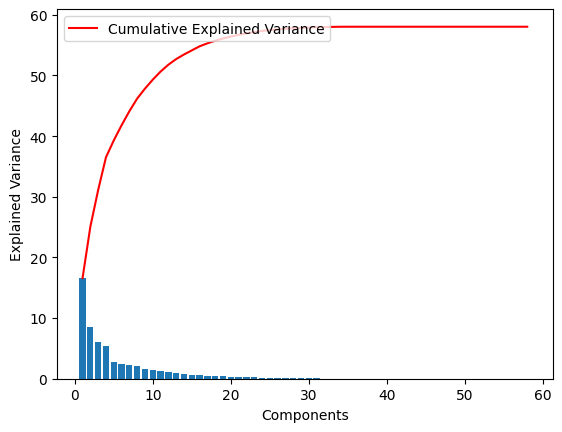

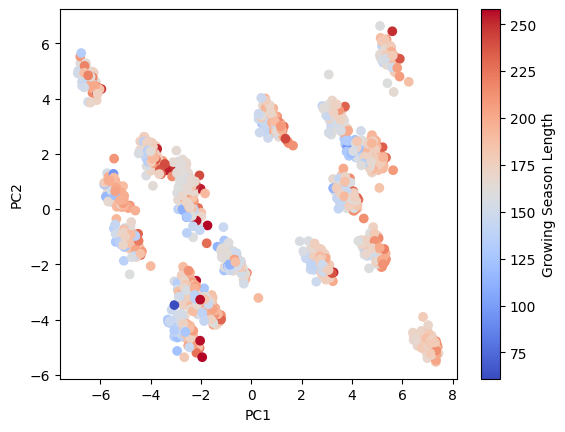

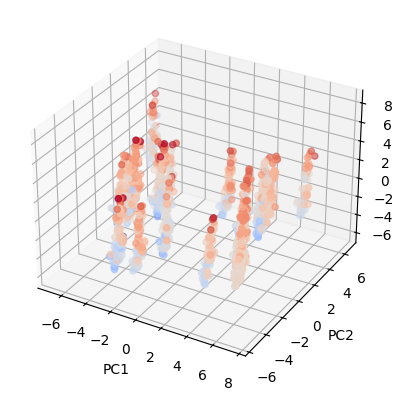

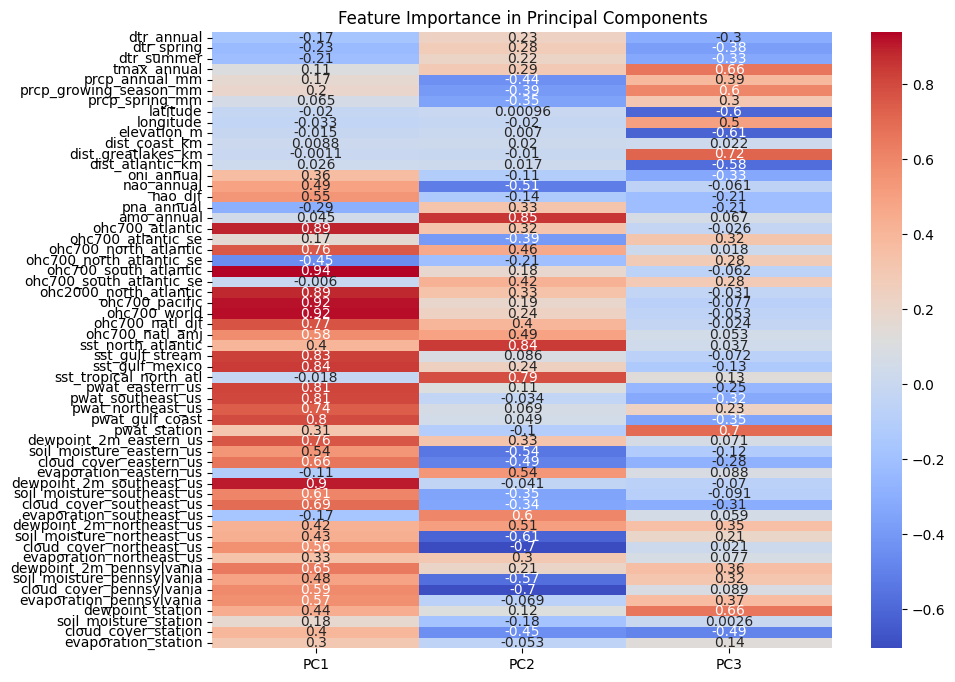

In [2]:
principal_component_analysis(X, y)

In the above table, the first principal component appears to be broadly composed of three main variables from various regions, those being OHC, SST, and PWAT.

Variables in the PC1 with importance coefficients above 0.8 include:
* Ocean Heat Content (Atlantic)
* Ocean Heat Content (South Atlantic)
* Ocean Heat Content (2000m North Atlantic)
* Ocean Heat Content (Pacific)
* Ocean Heat Content (World)
* Sea Surface Temperature (Gulf Stream)
* Sea Surface Temperature (Gulf of Mexico)
* Precipitable Water (Eastern U.S.)
* Precipitable Water (Southeastern U.S.)
* Precipitable Water (Gulf Coast)
* 2m Dewpoint (Southeast U.S.)

Based on this, I think it would be fair to consider this principal component primarily an oceanic impacts principal component, though the inclusion of precipitable water and the notable influence of a whole host of other atmospheric moisture variables with coefficients over 0.5 might suggest there is enough involvement from atmospheric moisture to merit its inclusion in the characterization of the principal component as well.

Reading the graph of explained variance, this first principal component, which I'll refer to as the Ocean/PWAT component, explains  approximately 17% of variance in growing season length across Pennsylvania.

Having also run the PCA analysis and PC loadings on Coastal (<150 km from atlantic ocean), Lakeside (<150 km from Great Lakes), and Inland (>150 km from both atlantic ocean and great lakes) stations, interesting deviations from the main first principal component loading include:

Coastal:
* PWAT (Eastern U.S.) and PWAT (Gulf Coast) coefficient technically dips below the arbitrarily set 0.8 threshold, but only to 0.79
* The aforementioned set of Northeast and Pennsylvania moisture variable coefficients (Dewpoint, Soil Moisture, Cloud Cover, and Evaporation) are all notably higher, but still only in the 0.5-0.7 coefficient range.

Lakeside:
* Notably, the lakeside subset is the smallest subset of the three by number of stations, so limited data could certainly play a role in the data.
* OHC (700m North Atlantic) dips slightly below the threshold of 0.8, but only to 0.78
* OHC (700m South Atlantic) has a coefficient of 0.95
* PWAT (Southeastern U.S.) and PWAT (Gulf Coast) coefficient technically dips below 0.8, but only to 0.79

Inland:
* OHC (700m North Atlantic) dips slightly below the threshold of 0.8, but only to 0.76
* The PC1 loadout for Inland is nearly a carbon copy of the PC1 loadout for the whole dataset, though as the Inland subset is far and away the largest subset, that isn't entirely surprising.

## Results and figures

*(Summarize key findings. Include any plots you made.)*

## Questions and blockers

- *(List anything you're stuck on or want to discuss at our next meeting.)*

## Plan for next week

- [ ] Next step 1
- [ ] Next step 2